Pulling results from both notebooks to join the together

In [1]:
import nbformat
from nbconvert.preprocessors import ExecutePreprocessor
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re

In [2]:
def load_notebook(notebook_path):
    with open(notebook_path, 'r') as f:
        nb = nbformat.read(f, as_version=4)

    # Execute the notebook in an isolated environment
    ep = ExecutePreprocessor(timeout=600, kernel_name='python3')
    ep.preprocess(nb, {'metadata': {'path': './'}})  # Run notebook in current directory
    globals_dict = {}
    exec("\n".join(cell.source for cell in nb.cells if cell.cell_type == "code"), globals_dict)
    if "sequence_df" in globals_dict:
        return globals_dict["sequence_df"]
    else:
        raise ValueError(f"'sequence_df' not found in {notebook_path}")

# Load DataFrames from both notebooks
directionality_df = load_notebook('directionality.ipynb')
time_between_detections_df = load_notebook('time_between_detections.ipynb')


Category '1': ['11', '12', '13']
Category '2': ['201', '202', '21', '22', '231', '232', '233']
Category '3': ['301', '302', '3A', '3B']
Category '4': ['401', '402', '41', '42', '44', '45']
Category '5': ['501', '51', '5A', '5B']
Category '6': ['61', '62', '6A', '6B', '6C', '6D', '6F']
Category '7': ['701', '702', '71', '7A', '7B', '7C', '7D']
Category '8': ['81', '82', '83', '84']
Category '9': ['91', '92', '921', '922', '9A', '9B', '9C', '9D', '9F']
Category 'others': ['A1', 'A2', 'AA', 'AB', 'C1', 'C2', '_C']
          tag_id                                                  0
0     989.001007       {'loc_code': ['61', '6A', '6B', '6A', '61']}
1     989.001007                 {'loc_code': ['22', '202', '201']}
2     989.001007       {'loc_code': ['6A', '6B', '6A', '6B', '6A']}
3     989.001007                   {'loc_code': ['61', '6A', '6B']}
4     989.001007                       {'loc_code': ['202', '201']}
...          ...                                                ...
6996  9

<string>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<string>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<string>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<string>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

          tag_id                                      sequence_data
0     989.001007  {'loc_code': ['61', '6A', '6B', '6A', '61'], '...
1     989.001007  {'loc_code': ['22', '202', '201'], 'time_betwe...
2     989.001007  {'loc_code': ['6A', '6B', '6A', '6B', '6A'], '...
3     989.001007  {'loc_code': ['61', '6A', '6B'], 'time_between...
4     989.001007  {'loc_code': ['202', '201'], 'time_between_det...
...          ...                                                ...
6996  989.002028  {'loc_code': ['91'], 'time_between_detections'...
6997  989.002028  {'loc_code': ['91', '922', '9A', '9B'], 'time_...
6998  989.002028  {'loc_code': ['91', '921', '922', '9A', '9B'],...
6999  989.002028  {'loc_code': ['91'], 'time_between_detections'...
7000  989.002028  {'loc_code': ['91', '922', '921', '922', '9B',...

[7001 rows x 2 columns]


In [3]:
directionality_df

,tag_id,loc_code,movement_direction
0,989.001007,"[61, 6A, 6B, 6A, 61]","[us, us, ds, ds]"
1,989.001007,"[22, 202, 201]","[us, ds]"
2,989.001007,"[6A, 6B, 6A, 6B, 6A]","[us, ds, us, ds]"
3,989.001007,"[61, 6A, 6B]","[us, us]"
4,989.001007,"[202, 201]",[ds]
...,...,...,...
6996,989.002028,[91],[]
6997,989.002028,"[91, 922, 9A, 9B]","[us, us, us]"
6998,989.002028,"[91, 921, 922, 9A, 9B]","[us, us, us, us]"
6999,989.002028,[91],[]


In [4]:
time_between_detections_df

,tag_id,loc_code,time_between_detections,number_of_detections,dwell_time
0,989.001007,"[61, 6A, 6B, 6A, 61]","[0 days 00:15:36.770000, 0 days 00:15:46.65000...","[3, 1, 6, 1, 4]","[0 days 00:11:33.050000, 0 days 00:00:00, 0 da..."
1,989.001007,"[22, 202, 201]","[14 days 21:54:52.150000, 0 days 00:05:54.7500...","[10, 1, 1]","[12 days 01:47:27.590000, 0 days 00:00:00, 0 d..."
2,989.001007,"[6A, 6B, 6A, 6B, 6A]","[0 days 00:00:06.370000, 0 days 00:00:16.13000...","[1, 6, 1, 14, 7]","[0 days 00:00:00, 0 days 00:15:31.480000, 0 da..."
3,989.001007,"[61, 6A, 6B]","[0 days 00:07:41.460000, 0 days 00:01:38.94000...","[2, 1, 3]","[0 days 00:01:08.920000, 0 days 00:00:00, 0 da..."
4,989.001007,"[202, 201]","[0 days 00:20:52.190000, NaT]","[1, 1]","[0 days 00:00:00, 0 days 00:00:00]"
...,...,...,...,...,...
6996,989.002028,[91],[NaT],[2],[0 days 23:58:30.190000]
6997,989.002028,"[91, 922, 9A, 9B]","[1 days 06:24:57.110000, 5 days 06:23:08.72000...","[1, 1, 1, 1]","[0 days 00:00:00, 0 days 00:00:00, 0 days 00:0..."
6998,989.002028,"[91, 921, 922, 9A, 9B]","[2 days 10:04:40.160000, 0 days 00:02:57.40000...","[1, 1, 2, 2, 2]","[0 days 00:00:00, 0 days 00:00:00, 0 days 00:0..."
6999,989.002028,[91],[NaT],[1],[0 days 00:00:00]


In [5]:
time_between_detections_df = time_between_detections_df.drop(columns=["loc_code"])  
merged_df = directionality_df.merge(time_between_detections_df, on="tag_id")  
merged_df = merged_df[['tag_id', 'loc_code', 'number_of_detections', 'dwell_time', 'movement_direction', 'time_between_detections']]
merged_df

,tag_id,loc_code,number_of_detections,dwell_time,movement_direction,time_between_detections
0,989.001007,"[61, 6A, 6B, 6A, 61]","[3, 1, 6, 1, 4]","[0 days 00:11:33.050000, 0 days 00:00:00, 0 da...","[us, us, ds, ds]","[0 days 00:15:36.770000, 0 days 00:15:46.65000..."
1,989.001007,"[22, 202, 201]","[10, 1, 1]","[12 days 01:47:27.590000, 0 days 00:00:00, 0 d...","[us, ds]","[14 days 21:54:52.150000, 0 days 00:05:54.7500..."
2,989.001007,"[6A, 6B, 6A, 6B, 6A]","[1, 6, 1, 14, 7]","[0 days 00:00:00, 0 days 00:15:31.480000, 0 da...","[us, ds, us, ds]","[0 days 00:00:06.370000, 0 days 00:00:16.13000..."
3,989.001007,"[61, 6A, 6B]","[2, 1, 3]","[0 days 00:01:08.920000, 0 days 00:00:00, 0 da...","[us, us]","[0 days 00:07:41.460000, 0 days 00:01:38.94000..."
4,989.001007,"[202, 201]","[1, 1]","[0 days 00:00:00, 0 days 00:00:00]",[ds],"[0 days 00:20:52.190000, NaT]"
...,...,...,...,...,...,...
6996,989.002028,[91],[2],[0 days 23:58:30.190000],[],[NaT]
6997,989.002028,"[91, 922, 9A, 9B]","[1, 1, 1, 1]","[0 days 00:00:00, 0 days 00:00:00, 0 days 00:0...","[us, us, us]","[1 days 06:24:57.110000, 5 days 06:23:08.72000..."
6998,989.002028,"[91, 921, 922, 9A, 9B]","[1, 1, 2, 2, 2]","[0 days 00:00:00, 0 days 00:00:00, 0 days 00:0...","[us, us, us, us]","[2 days 10:04:40.160000, 0 days 00:02:57.40000..."
6999,989.002028,[91],[1],[0 days 00:00:00],[],[NaT]


In [6]:
merged_df.to_csv("../data/tag summaries.csv", index=False)

In [7]:
unusual = merged_df[merged_df["movement_direction"].apply(lambda x: "unknown" in x)]
unusual

,tag_id,loc_code,number_of_detections,dwell_time,movement_direction,time_between_detections
94,989.001034,"[61, 61, 61]","[1, 2, 1]","[0 days 00:00:00, 41 days 16:49:34.700000, 0 d...","[unknown, unknown]","[0 days 00:17:31.940000, 0 days 11:53:05.49000..."
131,989.001034,"[7B, 7A, 71]","[18, 8, 3]","[0 days 00:16:29.200000, 0 days 00:06:59.15000...","[ds, unknown]","[0 days 00:00:24.840000, NaT, NaT]"
192,989.001034,"[7B, 7A, 7B, 7A, 7B, 71]","[1, 11, 1, 4, 1, 32]","[0 days 00:00:00, 0 days 01:22:09.380000, 0 da...","[ds, us, ds, us, unknown]","[0 days 00:00:47.110000, 0 days 00:01:11.05000..."
208,989.001034,"[9D, 9A, 9B]","[1, 1, 1]","[0 days 00:00:00, 0 days 00:00:00, 0 days 00:0...","[unknown, us]","[NaT, 0 days 00:00:03.070000, NaT]"
212,989.001034,"[9C, 9D, 91]","[1, 1, 2]","[0 days 00:00:00, 0 days 00:00:00, 2 days 04:5...","[unknown, ds]","[NaT, NaT, NaT]"
...,...,...,...,...,...,...
6687,989.001046,"[9D, 9C, 91, 922, 921, 922, 9A, 9B, 9A]","[1, 1, 2, 4, 1, 1, 1, 2, 1]","[0 days 00:00:00, 0 days 00:00:00, 0 days 19:2...","[unknown, ds, us, ds, us, us, us, ds]","[0 days 00:00:02.150000, 114 days 14:42:54.420..."
6689,989.002027,"[61, 61, 61]","[1, 1, 1]","[0 days 00:00:00, 0 days 00:00:00, 0 days 00:0...","[unknown, unknown]","[0 days 00:02:06.630000, 116 days 21:17:52.990..."
6711,989.002028,"[6A, 501]","[1, 3136]","[0 days 00:00:00, 161 days 17:54:54.640000]",[unknown],"[13 days 06:02:27.910000, NaT]"
6912,989.002028,"[922, 921, 9D, 9C, 9D, 9C, 9D, 9C, 9D, 9C, 9D,...","[1, 1, 1, 5, 1, 15, 12, 25, 17, 9, 8, 9, 3, 11...","[0 days 00:00:00, 0 days 00:00:00, 0 days 00:0...","[ds, unknown, unknown, unknown, unknown, unkno...","[0 days 00:00:34.200000, 0 days 21:48:35.76000..."


In [8]:
unusual.to_csv("../data/unusual movements.csv", index=False)

# Visualization

In [9]:
filtered_df = merged_df[~merged_df["movement_direction"].apply(lambda x: "unknown" in x)] # remove any "unknown"

In [10]:
all_items = [item for sublist in filtered_df['movement_direction'] for item in [sublist]]
counts = pd.Series(all_items).value_counts()
movement_counts = pd.DataFrame({'Combination': counts.index, 'Count': counts.values})
movement_counts

,Combination,Count
0,[],1545
1,[ds],687
2,[us],599
3,"[us, ds]",338
4,"[ds, us]",296
...,...,...
449,"[us, us, ds, us, us, ds, us, ds, us, ds, ds]",1
450,"[us, us, ds, us, ds, us, ds, us, ds, us, ds, u...",1
451,"[us, ds, ds, us, us, us, us, ds]",1
452,"[us, ds, us, ds, us, ds, us, ds, us, ds, us, d...",1


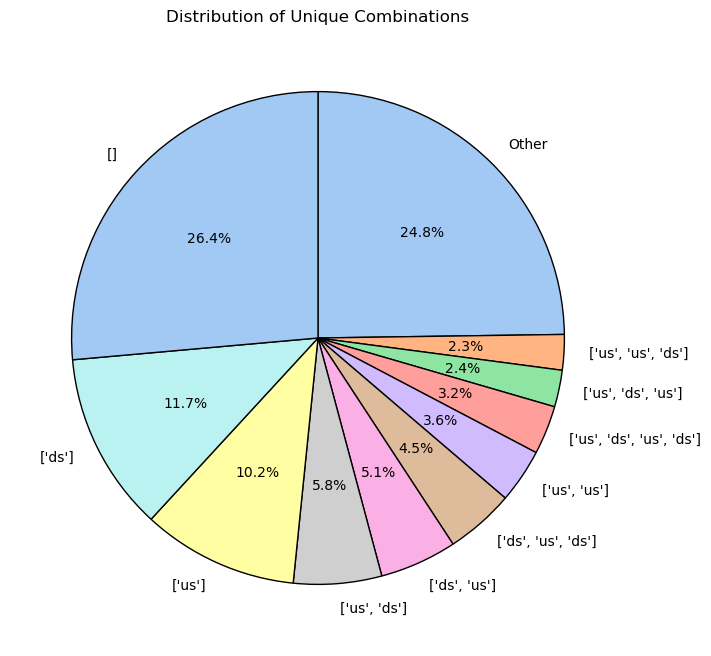

In [11]:
total_count = movement_counts["Count"].sum()

# 2% is considered the threshold, if the catagory has <2% = other
threshold = 0.02 * total_count

movement_counts["Category"] = np.where(movement_counts["Count"] < threshold, "Other", movement_counts["Combination"])
movement_counts["Combination"] = movement_counts["Combination"].astype(str)

movement_counts["Category"] = np.where(
    movement_counts["Count"] < threshold, "Other", movement_counts["Combination"]
)

pie_data = movement_counts.groupby("Category", as_index=False)["Count"].sum()

other_row = pie_data[pie_data["Category"] == "Other"]
pie_data = pie_data[pie_data["Category"] != "Other"]
pie_data = pie_data.sort_values(by="Count", ascending=True)

pie_data = pd.concat([other_row, pie_data], ignore_index=True)
custom_colors = sns.color_palette("pastel", len(pie_data))

plt.figure(figsize=(8,8))
plt.pie(pie_data["Count"], labels=pie_data["Category"], autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": "black"}, counterclock=False, colors=custom_colors)
plt.title("Distribution of Unique Combinations")
plt.show()

In [12]:
# filter rows with any Timedelta > 30 days
more_than_30 = filtered_df[filtered_df['time_between_detections'].apply(
    lambda x: any(td > pd.Timedelta(days=30) for td in x if pd.notna(td))
)]

more_than_30

,tag_id,loc_code,number_of_detections,dwell_time,movement_direction,time_between_detections
5,989.001007,"[402, 401, 402, 401, 402, 401, 402, 401, 402, ...","[14, 2, 1, 2, 10, 3, 3, 3, 3, 9, 2, 5, 3, 3, 2...","[51 days 14:41:06.450000, 0 days 00:25:20.3600...","[ds, us, ds, us, ds, us, ds, us, ds, us, ds, u...","[0 days 00:11:02.820000, 0 days 02:08:38.87000..."
10,989.001007,"[81, 84, 83, 84]","[1, 1, 1, 1]","[0 days 00:00:00, 0 days 00:00:00, 0 days 00:0...","[us, ds, us]","[514 days 09:31:53.870000, 0 days 00:15:07.520..."
11,989.001007,"[81, 83, 84]","[13, 1, 2]","[0 days 06:00:41.670000, 0 days 00:00:00, 0 da...","[us, us]","[516 days 11:03:46.420000, 0 days 00:02:06.610..."
12,989.001007,"[84, 82, 83]","[3, 1, 7]","[0 days 07:34:55.190000, 0 days 00:00:00, 0 da...","[ds, us]","[0 days 00:08:06.320000, 514 days 22:05:49.240..."
13,989.001007,"[84, 82, 83, 84]","[2, 1, 2, 1]","[0 days 00:30:07.250000, 0 days 00:00:00, 2 da...","[ds, us, us]","[0 days 03:04:56.590000, 203 days 16:59:36.330..."
...,...,...,...,...,...,...
6931,989.002028,"[301, 302, 301, 302, 301, 302, 301, 302, 301, ...","[2, 14, 1, 5, 2, 1, 1, 17, 1, 8, 1, 5, 1, 1, 1...","[0 days 01:47:42.370000, 7 days 03:31:32.38000...","[us, ds, us, ds, us, ds, us, ds, us, ds, us, d...","[0 days 07:45:11.100000, 0 days 17:56:32.32000..."
6937,989.002028,"[402, 401, 402]","[2, 1, 1]","[0 days 00:04:14.310000, 0 days 00:00:00, 0 da...","[ds, us]","[0 days 00:47:24.510000, 39 days 14:59:25.2000..."
6939,989.002028,"[401, 402, 401, 402, 401, 402, 401, 402, 401, ...","[1, 1, 9, 26, 8, 1, 2, 1, 1, 3, 1, 5, 2, 4, 8,...","[0 days 00:00:00, 0 days 00:00:00, 0 days 00:0...","[us, ds, us, ds, us, ds, us, ds, us, ds, us, d...","[0 days 00:01:03.070000, 0 days 04:44:25.72000..."
6953,989.002028,"[402, 401, 402, 401, 402, 401, 402, 401, 402, ...","[4, 7, 1, 1, 3, 73, 3, 2, 23, 1, 41, 1, 23, 1,...","[0 days 22:12:32.860000, 0 days 02:41:05.42000...","[ds, us, ds, us, ds, us, ds, us, ds, us, ds, u...","[1 days 00:26:21.140000, 0 days 21:27:48.27000..."


# Sankey attempt

In [13]:
sankey = more_than_30.loc[[16]] #taking random row
sankey['movement_direction'] = sankey['movement_direction'].apply(lambda x: x + [np.nan] if isinstance(x, list) else x)
# sankey['time_between_detections'] = sankey['time_between_detections'].apply(lambda x: x[:-1] if isinstance(x, list) and len(x) > 0 else x)
# sankey['time_between_detections'] = sankey['time_between_detections'].apply(lambda x: [np.nan] + x if isinstance(x, list) else x)

sankey

,tag_id,loc_code,number_of_detections,dwell_time,movement_direction,time_between_detections
16,989.001007,"[84, 82, 84, 83, 84]","[2, 1, 1, 3, 2]","[0 days 02:57:04.540000, 0 days 00:00:00, 0 da...","[ds, us, ds, us, nan]","[0 days 00:13:14.350000, 0 days 00:10:13.52000..."


In [14]:
columns_to_explode = ['loc_code', 'number_of_detections', 'movement_direction', 'time_between_detections']
sankey = sankey.explode(columns_to_explode)
sankey = pd.DataFrame(sankey)
sankey

,tag_id,loc_code,number_of_detections,dwell_time,movement_direction,time_between_detections
16,989.001007,84,2,"[0 days 02:57:04.540000, 0 days 00:00:00, 0 da...",ds,0 days 00:13:14.350000
16,989.001007,82,1,"[0 days 02:57:04.540000, 0 days 00:00:00, 0 da...",us,0 days 00:10:13.520000
16,989.001007,84,1,"[0 days 02:57:04.540000, 0 days 00:00:00, 0 da...",ds,514 days 07:38:42.900000
16,989.001007,83,3,"[0 days 02:57:04.540000, 0 days 00:00:00, 0 da...",us,0 days 01:50:41.730000
16,989.001007,84,2,"[0 days 02:57:04.540000, 0 days 00:00:00, 0 da...",NaN,NaT


In [15]:
type(sankey['time_between_detections'])

pandas.core.series.Series

In [16]:
# convert into sankey diagram format
source = sankey['loc_code'][0:len(sankey['loc_code'])-1]
target = sankey['loc_code'][1:len(sankey['loc_code'])]
value = sankey['number_of_detections'][0:len(sankey['loc_code'])-1] #change this to time between detections

sankey_df = {
    'Source' : source,
    'Target' : target,
    'Value' : value
}

sankey_df = pd.DataFrame(sankey_df)
sankey_df

,Source,Target,Value
16,84,82,2
16,82,84,1
16,84,83,1
16,83,84,3


In [17]:
import plotly.graph_objects as go

# # Sample data (Source, Target, Value)
# df_data = {
#     'Source': [84, 82, 84, 83 ],
#     'Target': [82, 84, 83, 84],
#     'Value': data['time_between_detections']
# }


labels = list(set(sankey_df['Source']).union(set(sankey_df['Target']))) # [83, 84, 82]
labels.sort()
label_to_index = {label: index for index, label in enumerate(labels)}  # {'83': 0, '84': 1, '82': 2}

# Prepare the Sankey data
sankey_data = {
    'type': 'sankey',
    'node': {
        'pad': 15,
        'thickness': 20,
        'line': {'color': "black", 'width': 0.5},
        'label': labels
    },
    'link': {
        'source': [label_to_index[source] for source in sankey_df['Source']],
        'target': [label_to_index[target] for target in sankey_df['Target']],
        'value': sankey_df['Value']
    }
}

# Create the figure
fig = go.Figure(go.Sankey(sankey_data))
fig.update_layout(title_text="Sankey Diagram", font_size=10)
fig.show()


This was supposed to be 84-82-84-83-84